# TCN + GRU + XGBoost — NASA C-MAPSS Anomaly Detection (v2)

## Mimari
```
Sensor Sequence (T x F)
       |
  ┌────┴────┐
  TCN       GRU
  (causal   (bidirectional
   dilated)  + attn pool)
  Attn Pool  Attn Pool
  ↓          ↓
  emb_tcn   emb_gru
  └────┬────┘
   Concat + Handcrafted Stats
       ↓
   XGBoost Classifier
```

**Geliştirmeler (v2):**
- Engine-based val split → veri sızıntısı yok
- Temporal attention pooling (TCN + GRU)
- Focal Loss (class imbalance)
- Handcrafted istatistiksel özellikler embedding'e ekleniyor
- XGBoost: reg_alpha, reg_lambda, min_child_weight eklendi
- PR-AUC metriği eklendi

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Kurulum & Import

In [32]:
!pip install -q xgboost

In [33]:
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
import xgboost as xgb

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## 2. Konfigürasyon

In [34]:
BASE = '/content/drive/MyDrive/data'

CFG = {
    # Data
    'rul_threshold': 30,
    'seq_len': 30,
    'stride': 1,
    'val_engine_frac': 0.15,   # motorların %15'i val'a ayrılır (sızıntısız)

    # TCN
    'tcn_channels': [64, 128, 128],
    'tcn_kernel': 3,

    # GRU
    'gru_hidden': 64,
    'gru_layers': 2,

    # Embedding
    'embed_dim': 128,

    # Training
    'epochs': 50,
    'batch_size': 512,
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'patience': 10,
    'focal_gamma': 2.0,    # Focal Loss gamma (0 = BCE)

    # XGBoost
    'xgb_rounds': 600,
    'xgb_lr': 0.05,
    'xgb_depth': 6,
    'xgb_subsample': 0.8,
    'xgb_colsample': 0.8,
    'xgb_min_child': 5,
    'xgb_reg_alpha': 0.1,
    'xgb_reg_lambda': 1.0,
}

## 3. Veri Yükleme & Ön İşleme

In [35]:
COLUMNS = (
    ['unit_number', 'time_in_cycles']
    + [f'op_{i}' for i in range(1, 4)]
    + [f's{i}' for i in range(1, 22)]
)
DROP_SENSORS = ['s1', 's5', 's6', 's10', 's16', 's18', 's19']


def load_raw(fd='FD001'):
    train = pd.read_csv(f'{BASE}/train_{fd}.txt', sep=r'\s+', header=None, names=COLUMNS)
    test  = pd.read_csv(f'{BASE}/test_{fd}.txt',  sep=r'\s+', header=None, names=COLUMNS)
    rul   = pd.read_csv(f'{BASE}/RUL_{fd}.txt',   header=None, names=['RUL'])
    return train, test, rul


def add_rul(df):
    max_c = df.groupby('unit_number')['time_in_cycles'].max()
    df = df.join(max_c.rename('max_c'), on='unit_number')
    df['RUL'] = df['max_c'] - df['time_in_cycles']
    return df.drop('max_c', axis=1)


def get_features(df):
    sensor_cols = [c for c in df.columns if c.startswith('s') and c not in DROP_SENSORS]
    return sensor_cols + ['op_1', 'op_2', 'op_3']


def normalize(train_df, test_df, feat_cols):
    scaler = StandardScaler()
    train_df, test_df = train_df.copy(), test_df.copy()
    train_df[feat_cols] = scaler.fit_transform(train_df[feat_cols])
    test_df[feat_cols]  = scaler.transform(test_df[feat_cols])
    return train_df, test_df, scaler


def make_sequences(df, feat_cols, rul_threshold, seq_len, stride=1):
    X_list, y_list, uid_list = [], [], []
    for uid, grp in df.groupby('unit_number'):
        vals   = grp[feat_cols].values.astype(np.float32)
        labels = (grp['RUL'].values < rul_threshold).astype(np.float32)
        n = len(vals)
        for start in range(0, n - seq_len + 1, stride):
            X_list.append(vals[start:start+seq_len])
            y_list.append(labels[start+seq_len-1])
            uid_list.append(uid)
    return np.array(X_list, dtype=np.float32), np.array(y_list), np.array(uid_list)


def make_test_sequences(test_df, rul_df, feat_cols, rul_threshold, seq_len):
    X_last, y_last = [], []
    X_all,  y_all  = [], []
    for uid, grp in test_df.groupby('unit_number'):
        vals = grp[feat_cols].values.astype(np.float32)
        n = len(vals)
        true_rul_last = rul_df.iloc[uid - 1]['RUL']
        label_last = int(true_rul_last < rul_threshold)

        # test_last
        if n >= seq_len:
            X_last.append(vals[-seq_len:])
        else:
            pad = np.zeros((seq_len - n, vals.shape[1]), dtype=np.float32)
            X_last.append(np.vstack([pad, vals]))
        y_last.append(label_last)

        # test_all
        for start in range(0, n - seq_len + 1):
            steps_from_end = n - (start + seq_len - 1) - 1
            approx_rul = true_rul_last + steps_from_end
            X_all.append(vals[start:start+seq_len])
            y_all.append(int(approx_rul < rul_threshold))

    return (
        np.array(X_last, dtype=np.float32), np.array(y_last, dtype=np.int32),
        np.array(X_all,  dtype=np.float32), np.array(y_all,  dtype=np.int32),
    )


def extract_handcrafted(X):
    """
    Sequence istatistiksel ozellikler: her sensor icin
    mean, std, min, max, trend (son-ilk), peak-to-peak
    Shape: (N, F*6)
    """
    feats = []
    feats.append(X.mean(axis=1))                  # (N, F)
    feats.append(X.std(axis=1))                   # (N, F)
    feats.append(X.min(axis=1))                   # (N, F)
    feats.append(X.max(axis=1))                   # (N, F)
    feats.append(X[:, -1, :] - X[:, 0, :])       # trend
    feats.append(X.max(axis=1) - X.min(axis=1))  # peak-to-peak
    return np.concatenate(feats, axis=1).astype(np.float32)


def prepare_fd(fd='FD001', cfg=CFG):
    train_raw, test_raw, rul_df = load_raw(fd)
    train_raw = add_rul(train_raw)
    feat_cols  = get_features(train_raw)
    train_raw, test_raw, scaler = normalize(train_raw, test_raw, feat_cols)

    X, y, uids = make_sequences(train_raw, feat_cols,
                                cfg['rul_threshold'], cfg['seq_len'], cfg['stride'])

    # ── Engine-based val split (sızıntısız) ──────────────────────────────
    all_engines = np.unique(uids)
    rng = np.random.RandomState(42)
    rng.shuffle(all_engines)
    n_val_engines = max(1, int(len(all_engines) * cfg['val_engine_frac']))
    val_engines = set(all_engines[:n_val_engines])

    val_mask = np.array([u in val_engines for u in uids])
    tr_mask  = ~val_mask

    X_tr, y_tr   = X[tr_mask],  y[tr_mask]
    X_val, y_val = X[val_mask], y[val_mask]

    X_tl, y_tl, X_tall, y_tall = make_test_sequences(
        test_raw, rul_df, feat_cols, cfg['rul_threshold'], cfg['seq_len']
    )

    hc_tr   = extract_handcrafted(X_tr)
    hc_val  = extract_handcrafted(X_val)
    hc_tl   = extract_handcrafted(X_tl)
    hc_tall = extract_handcrafted(X_tall)

    n_feat = X.shape[2]
    print(f'  {fd} | train={X_tr.shape} val={X_val.shape} | '
          f'test_last={X_tl.shape} test_all={X_tall.shape} | '
          f'feat={n_feat}  hc_feat={hc_tr.shape[1]}')
    print(f'        pos_ratio  tr={y_tr.mean():.3f}  val={y_val.mean():.3f}  '
          f'tl={y_tl.mean():.3f}  tall={y_tall.mean():.3f}')

    return {
        'X_tr': X_tr, 'y_tr': y_tr, 'hc_tr': hc_tr,
        'X_val': X_val, 'y_val': y_val, 'hc_val': hc_val,
        'X_tl': X_tl,   'y_tl': y_tl,   'hc_tl': hc_tl,
        'X_tall': X_tall, 'y_tall': y_tall, 'hc_tall': hc_tall,
        'n_feat': n_feat,
    }

## 4. Model: TCN + GRU Encoder

In [ ]:
# ── Temporal Attention Pooling ────────────────────────────────────────────
class TemporalAttention(nn.Module):
    """Tum timestep'lere ogrenilmis agirlik verir, son adim yerine."""
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Linear(dim, 1)

    def forward(self, x):   # x: (B, T, C)
        w = torch.softmax(self.score(x), dim=1)   # (B, T, 1)
        return (w * x).sum(dim=1)                  # (B, C)

class CausalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, dilation=1, dropout=0.1):
        super().__init__()
        pad = (kernel - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel, dilation=dilation, padding=pad)
        self.trim = pad
        self.norm = nn.BatchNorm1d(out_ch)
        self.drop = nn.Dropout(dropout)
        self.res  = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):       # x: (B, C, T)
        out = self.conv(x)
        if self.trim:
            out = out[:, :, :-self.trim]
        out = F.gelu(self.norm(out))
        return self.drop(out) + self.res(x)

class TCNBranch(nn.Module):
    def __init__(self, n_feat, channels, kernel=3, dropout=0.1):
        super().__init__()
        layers, in_ch = [], n_feat
        for i, out_ch in enumerate(channels):
            layers.append(CausalBlock(in_ch, out_ch, kernel, 2**i, dropout))
            in_ch = out_ch
        self.net  = nn.Sequential(*layers)
        self.attn = TemporalAttention(channels[-1])
        self.out_dim = channels[-1]

    def forward(self, x):               # x: (B, T, F)
        h = self.net(x.permute(0, 2, 1))  # (B, C, T)
        h = h.permute(0, 2, 1)            # (B, T, C)
        return self.attn(h)               # (B, C)


# ── GRU Branch (attention pooling over all hidden states) ─────────────────
class GRUBranch(nn.Module):
    def __init__(self, n_feat, hidden, n_layers=2, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(
            n_feat, hidden, n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.attn    = TemporalAttention(hidden * 2)
        self.out_dim = hidden * 2

    def forward(self, x):           # x: (B, T, F)
        out, _ = self.gru(x)        # out: (B, T, hidden*2)
        return self.attn(out)       # (B, hidden*2)


# ── Focal Loss ─────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none'
        )
        prob = torch.sigmoid(logits)
        pt   = torch.where(targets == 1, prob, 1 - prob)
        return ((1 - pt) ** self.gamma * bce).mean()


# ── TCN-GRU Encoder ───────────────────────────────────────────────────────
class TCNGRUEncoder(nn.Module):
    def __init__(self, n_feat, cfg):
        super().__init__()
        self.tcn = TCNBranch(n_feat, cfg['tcn_channels'], cfg['tcn_kernel'])
        self.gru = GRUBranch(n_feat, cfg['gru_hidden'],   cfg['gru_layers'])

        fused_dim = self.tcn.out_dim + self.gru.out_dim
        self.proj = nn.Sequential(
            nn.Linear(fused_dim, cfg['embed_dim']),
            nn.LayerNorm(cfg['embed_dim']),
            nn.GELU(),
            nn.Dropout(0.2),
        )
        self.head = nn.Linear(cfg['embed_dim'], 1)

    def forward(self, x):
        fused = torch.cat([self.tcn(x), self.gru(x)], dim=-1)
        emb   = self.proj(fused)
        return emb, self.head(emb).squeeze(-1)

## 5. Eğitim Döngüsü (Phase 1 — Neural Net Pre-training)

In [37]:
def train_encoder(data, cfg=CFG, device=DEVICE):
    X_tr, y_tr   = data['X_tr'], data['y_tr']
    X_val, y_val = data['X_val'], data['y_val']

    tr_ds  = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr))
    val_ds = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
    tr_loader  = DataLoader(tr_ds,  batch_size=cfg['batch_size'], shuffle=True,  drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=cfg['batch_size'], shuffle=False)

    model = TCNGRUEncoder(data['n_feat'], cfg).to(device)

    pos_w = torch.tensor(
        [(1 - y_tr.mean()) / (y_tr.mean() + 1e-6)], dtype=torch.float32
    ).to(device)
    criterion = FocalLoss(gamma=cfg['focal_gamma'], pos_weight=pos_w)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg['epochs'])

    best_val_loss = float('inf')
    best_state    = None
    patience_cnt  = 0

    for epoch in range(1, cfg['epochs'] + 1):
        model.train()
        tr_loss = 0.0
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            _, logit = model(xb)
            loss = criterion(logit, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_loss += loss.item() * len(xb)
        tr_loss /= len(tr_ds)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                _, logit = model(xb)
                val_loss += criterion(logit, yb).item() * len(xb)
        val_loss /= len(val_ds)
        scheduler.step()

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:03d}/{cfg["epochs"]}  '
                  f'tr={tr_loss:.4f}  val={val_loss:.4f}')

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt  = 0
        else:
            patience_cnt += 1
            if patience_cnt >= cfg['patience']:
                print(f'  Early stop @ epoch {epoch}')
                break

    model.load_state_dict(best_state)
    model.eval()
    print(f'  Best val_loss = {best_val_loss:.4f}')
    return model


def extract_embeddings(model, X, device=DEVICE, batch_size=1024):
    model.eval()
    embs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i+batch_size]).to(device)
            emb, _ = model(xb)
            embs.append(emb.cpu().numpy())
    return np.vstack(embs)

## 6. XGBoost Aşaması (Phase 2)

In [38]:
from sklearn.metrics import average_precision_score


def best_threshold(y_true, proba):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.05, 0.95, 0.01):
        f1 = f1_score(y_true, (proba >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


def train_xgboost(emb_tr, hc_tr, y_tr, emb_val, hc_val, y_val, cfg=CFG):
    # Embedding + handcrafted birlesimi
    X_tr  = np.concatenate([emb_tr,  hc_tr],  axis=1)
    X_val = np.concatenate([emb_val, hc_val], axis=1)

    pos_ratio = y_tr.sum() / len(y_tr)
    spw = (1 - pos_ratio) / (pos_ratio + 1e-6)

    dtrain = xgb.DMatrix(X_tr,  label=y_tr)
    dval   = xgb.DMatrix(X_val, label=y_val)

    params = {
        'objective':        'binary:logistic',
        'eval_metric':      'logloss',
        'learning_rate':    cfg['xgb_lr'],
        'max_depth':        cfg['xgb_depth'],
        'subsample':        cfg['xgb_subsample'],
        'colsample_bytree': cfg['xgb_colsample'],
        'min_child_weight': cfg['xgb_min_child'],
        'reg_alpha':        cfg['xgb_reg_alpha'],
        'reg_lambda':       cfg['xgb_reg_lambda'],
        'scale_pos_weight': spw,
        'seed': 42,
        'verbosity': 0,
        'tree_method': 'hist',
        'device': 'cuda' if DEVICE == 'cuda' else 'cpu',
    }

    bst = xgb.train(
        params, dtrain,
        num_boost_round=cfg['xgb_rounds'],
        evals=[(dval, 'val')],
        early_stopping_rounds=30,
        verbose_eval=50,
    )

    val_proba = bst.predict(dval)
    thr, val_f1 = best_threshold(y_val, val_proba)
    val_auc = roc_auc_score(y_val, val_proba)
    print(f'  Best threshold={thr:.4f}  val_F1={val_f1:.4f}  val_AUC={val_auc:.4f}')
    return bst, thr


def evaluate(bst, thr, emb, hc, y_true, tag):
    X    = np.concatenate([emb, hc], axis=1)
    dmat = xgb.DMatrix(X)
    proba = bst.predict(dmat)
    pred  = (proba >= thr).astype(int)

    f1   = f1_score(y_true, pred, zero_division=0)
    auc  = roc_auc_score(y_true, proba)
    prauc = average_precision_score(y_true, proba)
    cm   = confusion_matrix(y_true, pred)
    tn, fp, fn, tp = cm.ravel() if cm.shape == (2, 2) else (0, 0, 0, 0)

    print(f'  [{tag}]  F1={f1:.4f}  AUC={auc:.4f}  PR-AUC={prauc:.4f}  '
          f'TP={tp}  FP={fp}  FN={fn}')
    print(classification_report(y_true, pred, target_names=['normal', 'anomaly'], digits=4))
    return f1, auc, prauc, tp, fp, fn

## 7. Tam Pipeline — Tüm Dataset'ler

In [39]:
DATASETS = ['FD001', 'FD002', 'FD003', 'FD004']
summary  = []

for fd in DATASETS:
    print('\n' + '='*65)
    print(f'  {fd}')
    print('='*65)

    data = prepare_fd(fd, CFG)

    print('\n[Phase 1] TCN+GRU pre-training...')
    encoder = train_encoder(data, CFG, DEVICE)

    print('\n[Embedding extraction]')
    emb_tr   = extract_embeddings(encoder, data['X_tr'],   DEVICE)
    emb_val  = extract_embeddings(encoder, data['X_val'],  DEVICE)
    emb_tl   = extract_embeddings(encoder, data['X_tl'],   DEVICE)
    emb_tall = extract_embeddings(encoder, data['X_tall'], DEVICE)
    print(f'  emb shape: {emb_tr.shape}  hc shape: {data["hc_tr"].shape}')

    print('\n[Phase 2] XGBoost training...')
    bst, thr = train_xgboost(
        emb_tr,  data['hc_tr'],  data['y_tr'],
        emb_val, data['hc_val'], data['y_val'],
        CFG,
    )

    print(f'\n[Evaluation — {fd}]')
    f1_tl,   auc_tl,   prauc_tl,   tp_tl,  fp_tl,  fn_tl  = evaluate(
        bst, thr, emb_tl,   data['hc_tl'],   data['y_tl'],   f'{fd} test_last')
    f1_tall, auc_tall, prauc_tall, tp_tall, fp_tall, fn_tall = evaluate(
        bst, thr, emb_tall, data['hc_tall'], data['y_tall'], f'{fd} test_all')

    summary.append({
        'Dataset':        fd,
        'F1 last':        round(f1_tl,    4),
        'AUC last':       round(auc_tl,   4),
        'PR-AUC last':    round(prauc_tl, 4),
        'TP/FP/FN last':  f'{tp_tl}/{fp_tl}/{fn_tl}',
        'F1 all':         round(f1_tall,    4),
        'AUC all':        round(auc_tall,   4),
        'PR-AUC all':     round(prauc_tall, 4),
    })

    del encoder
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

print('\n' + '='*80)
print('  OZET TABLO')
print('='*80)
df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))
print('='*80)


  FD001
  FD001 | train=(15104, 30, 17) val=(2627, 30, 17) | test_last=(100, 30, 17) test_all=(10196, 30, 17) | feat=17  hc_feat=102
        pos_ratio  tr=0.169  val=0.171  tl=0.250  tall=0.030

[Phase 1] TCN+GRU pre-training...
  Epoch 001/50  tr=0.0883  val=0.0696
  Epoch 005/50  tr=0.0190  val=0.1001
  Epoch 010/50  tr=0.0124  val=0.1667
  Early stop @ epoch 13
  Best val_loss = 0.0633

[Embedding extraction]
  emb shape: (15104, 128)  hc shape: (15104, 102)

[Phase 2] XGBoost training...
[0]	val-logloss:0.64923
[50]	val-logloss:0.13092
[100]	val-logloss:0.12450
[102]	val-logloss:0.12554
  Best threshold=0.8800  val_F1=0.9033  val_AUC=0.9877

[Evaluation — FD001]
  [FD001 test_last]  F1=0.8095  AUC=0.9883  PR-AUC=0.9653  TP=17  FP=0  FN=8
              precision    recall  f1-score   support

      normal     0.9036    1.0000    0.9494        75
     anomaly     1.0000    0.6800    0.8095        25

    accuracy                         0.9200       100
   macro avg     0.9518    0.

## 8. Özet Görselleştirme

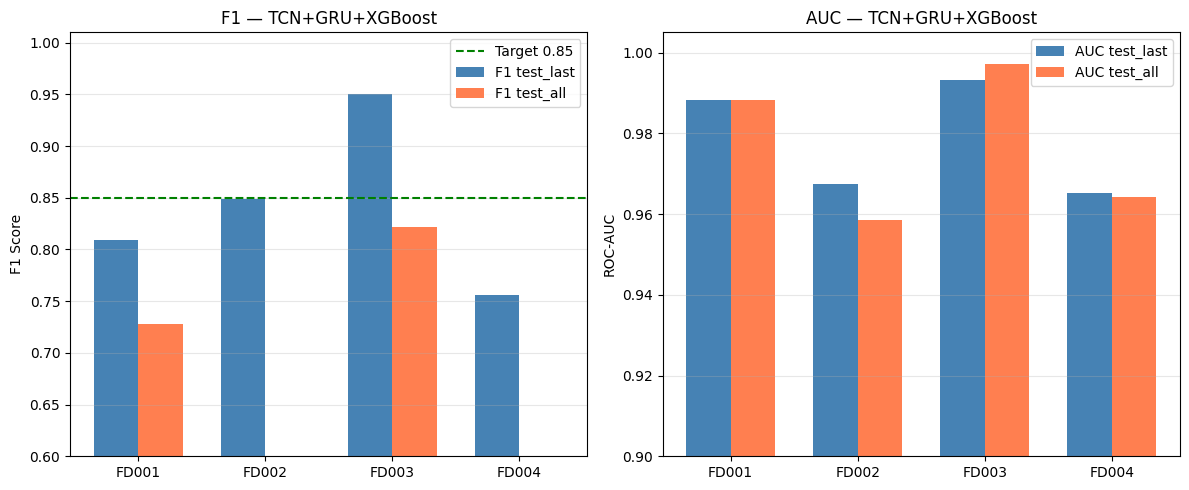

Kaydedildi: /content/tcn_gru_xgboost_results.png


In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ds_labels = df_summary['Dataset'].tolist()
x = np.arange(len(ds_labels))
w = 0.35

ax = axes[0]
ax.bar(x - w/2, df_summary['F1 last'], w, label='F1 test_last', color='steelblue')
ax.bar(x + w/2, df_summary['F1 all'],  w, label='F1 test_all',  color='coral')
ax.axhline(0.85, ls='--', color='green', lw=1.5, label='Target 0.85')
ax.set_xticks(x); ax.set_xticklabels(ds_labels)
ax.set_ylim(0.6, 1.01); ax.set_ylabel('F1 Score')
ax.set_title('F1 — TCN+GRU+XGBoost')
ax.legend(); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.bar(x - w/2, df_summary['AUC last'], w, label='AUC test_last', color='steelblue')
ax.bar(x + w/2, df_summary['AUC all'],  w, label='AUC test_all',  color='coral')
ax.set_xticks(x); ax.set_xticklabels(ds_labels)
ax.set_ylim(0.9, 1.005); ax.set_ylabel('ROC-AUC')
ax.set_title('AUC — TCN+GRU+XGBoost')
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/tcn_gru_xgboost_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Kaydedildi: /content/tcn_gru_xgboost_results.png')